In [ ]:
from paddleocr import PaddleOCR, draw_ocr
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time 
from PIL import Image, ImageDraw, ImageFont

In [ ]:
# 模型路径下必须含有model和params文件
PaddleOCR_Path = "E:\\code\\git\\PaddleOCR"
det_model_dir = './inference/det_ppocrv3/Student'
rec_model_dir="./inference/rec_ppocrv3/Student"
rec_char_dict_path='ppocr/utils/ppocr_keys_v1.txt'

ocr = PaddleOCR(det_model_dir=os.path.join(PaddleOCR_Path, det_model_dir) ,
 rec_model_dir=os.path.join(PaddleOCR_Path, rec_model_dir), 
 rec_char_dict_path=os.path.join(PaddleOCR_Path, rec_char_dict_path),
 use_gpu = True
 )

In [ ]:
def draw_result(img_path, fontStyle, result, match_dict):
    image = Image.open(img_path)
    drawBoard = np.ones_like(np.array(image), dtype=np.uint8) * 255
    drawBoard = Image.fromarray(drawBoard)
    draw = ImageDraw.Draw(drawBoard)
        # 字体的格式
    
    for _unit_key in ['20°', '60°','85°']:
        # 每一行取出来
        _row = match_dict[_unit_key]
        for _box in _row:
            _index = _box[0]
            left_top = result[_index][0][0]
            left_top = (int(left_top[0]), int(left_top[1]))
            w = result[_index][0][1][0] - result[_index][0][0][0]
            h = result[_index][0][3][1] - result[_index][0][0][1]
            text = result[_index][1][0]
            # cv2.putText(drawBoard, text, left_top, cv2.FONT_HERSHEY_SIMPLEX, fontScale=3, color=(0,0,255), thickness=6)
            draw.text(left_top, text, (0,0,255), font=fontStyle, align='left')
            
    plt.figure(figsize=(18,24))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.subplot(1,2,2)
    plt.imshow(drawBoard)

In [34]:
def find_data(result, y_limit):
    # print(result)
    # 1求取中心点，用四个点的1/4来计算
    _center_M = np.array([[0.25, 0.25, 0.25, 0.25]], dtype=np.float32)
    result_center = []
    for _i, _it in enumerate(result):
        _box = _it[0]
        _box = np.array(_box).astype(np.float32)
        _center = _center_M @ _box
        result_center.append([_i, _center, _it[-1]]) # 加上索引便于后面使用
        
    # 2把代表单位列的检测结果添加到列表
    unit_line = []
    for _i, _it in enumerate(result_center):
        if _it[-1][0] in ['20°', '60°','85°']  :
            unit_line.append(_it) 
    
    # 开始匹配对应的数据        
    # y_limit = 100
    num = 3
    match_dict = {}
    for _unit in unit_line:
        sub_list = []
        for _item in result_center:
            if _item[-1][0] not in ['20°', '60°','85°']:
                _y_dis = _item[1][0][1] - _unit[1][0][1]
                if abs(_y_dis) < y_limit:
                    sub_list.append(_item)
        sub_list.append(_unit)
        match_dict[_unit[-1][0]] = sub_list
        
    # 对结果排序
    _key = lambda x: x[1][0][0]
    for _unit_key in ['20°', '60°','85°']:
        try:
            list.sort(match_dict[_unit_key], key=_key)
        except:
            pass
        
    return match_dict

In [35]:
img_path = 'C:\\Users\\hp\\Desktop\\imgs_b2\\6.jpg'
t0 = time.time()
result = ocr.ocr(img_path)
print("cost time: ", time.time()-t0)

[2022/08/15 17:31:50] ppocr WARNING: Since the angle classifier is not initialized, the angle classifier will not be uesd during the forward process
[2022/08/15 17:31:51] ppocr DEBUG: dt_boxes num : 17, elapse : 0.44192075729370117
[2022/08/15 17:31:51] ppocr DEBUG: rec_res num  : 17, elapse : 0.1589794158935547
cost time:  0.654475212097168


In [36]:
match_dict = find_data(result, y_limit=30)

font_path=os.path.join(PaddleOCR_Path, 'doc/fonts/simfang.ttf')
fontStyle = ImageFont.truetype(
        font_path, 80, encoding="utf-8")

draw_result(img_path, fontStyle, result, match_dict)

KeyError: '20°'

In [ ]:
# print(len(match_dict['20°']))
match_dict_new = {}
for key in match_dict:
    # print(item)
    if len(match_dict[key]) >=4:
        match_dict_new[key]= match_dict[key][0:4]
    else:
        match_dict_new[key]= match_dict[key]

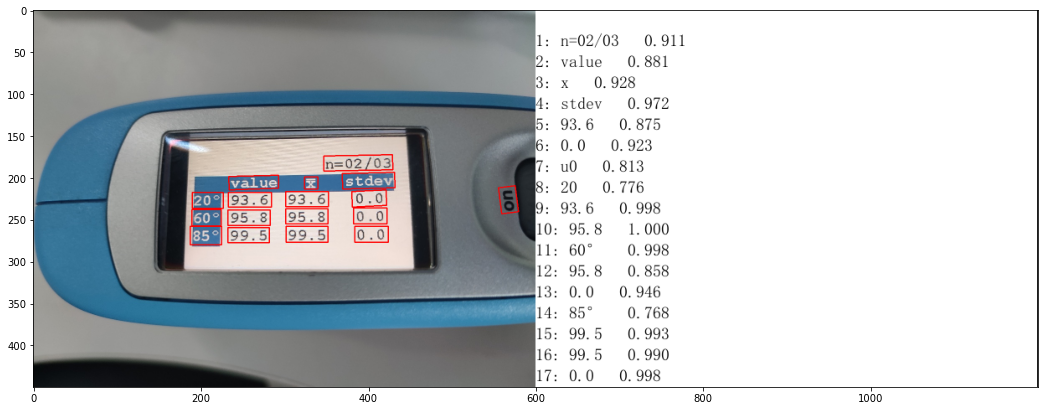

In [33]:
# 显示结果

image = Image.open(img_path).convert('RGB')
boxes = [line[0] for line in result]
txts = [line[1][0] for line in result]
scores = [line[1][1] for line in result]
im_show = draw_ocr(image, boxes, txts, scores, font_path=os.path.join(PaddleOCR_Path, 'doc/fonts/simfang.ttf'))
plt.figure(figsize=(18,24))
plt.imshow(im_show)
# im_show = Image.fromarray(im_show)
# im_show.save('result2.jpg')

In [ ]:
# print(result)
_center_M = np.array([[0.25, 0.25, 0.25, 0.25]], dtype=np.float32)
result_center = []
for _i, _it in enumerate(result):
    _box = _it[0]
    _box = np.array(_box).astype(np.float32)
    _center = _center_M @ _box
    result_center.append([_i, _center, _it[-1]])
    

In [ ]:
unit_line = []
for _i, _it in enumerate(result_center):
    if _it[-1][0] in ['20°', '60°','85°']:
        unit_line.append(_it) 

In [ ]:
y_limit = 100
num = 3
match_dict = {}
for _unit in unit_line:
    sub_list = []
    for _item in result_center:
        if _item[-1][0] not in ['20°', '60°','85°']:
            _y_dis = _item[1][0][1] - _unit[1][0][1]
            if abs(_y_dis) < y_limit:
                sub_list.append(_item)
    sub_list.append(_unit)
    match_dict[_unit[-1][0]] = sub_list
                

In [ ]:
print(match_dict)

In [ ]:
_it = match_dict['20°']
print(_it)

# _key = lambda x: x[1][0][0]
# print(list.sort(_it, key=_key))


In [ ]:
print(_it)

In [ ]:
_key = lambda x: x[1][0][0]
for _unit_key in ['20°', '60°','85°']:
    list.sort(match_dict[_unit_key], key=_key)

In [ ]:

image = cv2.imread(img_path)
drawBoard = np.ones_like(image, dtype=np.uint8) * 255
for _unit_key in ['20°', '60°','85°']:
    # 每一行取出来
    _row = match_dict[_unit_key]
    for _box in _row:
        _index = _box[0]
        left_bottom = result[_index][0][3]
        left_bottom = (int(left_bottom[0]), int(left_bottom[1]))
        w = result[_index][0][1][0] - result[_index][0][0][0]
        h = result[_index][0][3][1] - result[_index][0][0][1]
        text = result[_index][1][0]
        cv2.putText(drawBoard, text, left_bottom, cv2.FONT_HERSHEY_COMPLEX, fontScale=3, color=(0,0,255), thickness=6)
        


In [ ]:


img_src = cv2.imread(img_path)
plt.figure(figsize=(18,24))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_src, cv2.COLOR_BGR2RGB))
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(drawBoard, cv2.COLOR_BGR2RGB))